In [1]:
import sys
sys.path.append("/Users/emilieyu/endotehelial-masboss")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import copy


from abm.membrane_node import MembraneNode
from abm.flow_field import FlowField
from abm.spring import Spring
from abm.stress_fibre import StressFibre
from abm.endothelial_cell import EndothelialCell
from abm.rho_lookup_table import RhoLookupTable
from src.config import load_abm_sim_cfg
from src.paths import BM_RESULTS_DIR

CFG = load_abm_sim_cfg()
lut = RhoLookupTable(CFG, BM_RESULTS_DIR)
flow = FlowField()
from abm.signalling import get_protein_recruitment
from abm.scripts.run_abm_sim import run_abm_sim_single, run_abm_sim
from abm.analysis.cell_measurement import measure_forces



>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.463 RhoC=0.437


# TEST RUNS

In [2]:

def plot_cell(cell, ax=None, show_ids=True):
    """
    Very basic visualisation of the cell.

    Shows:
        - membrane nodes (with optional IDs)
        - centroid
        - cortical springs
        - stress fibres
        - FA anchor points
    """
    if ax is None:
        fig, ax = plt.subplots()

    # -------------------------
    # Nodes
    # -------------------------
    xs = [n.pos[0] for n in cell.nodes]
    ys = [n.pos[1] for n in cell.nodes]

    ax.scatter(xs, ys)

    # Label node IDs
    if show_ids:
        for n in cell.nodes:
            ax.text(n.pos[0], n.pos[1], str(n.id), fontsize=8)

    # -------------------------
    # Springs (membrane edges)
    # -------------------------
    for s in cell.springs:
        x = [s.node_1.pos[0], s.node_2.pos[0]]
        y = [s.node_1.pos[1], s.node_2.pos[1]]
        ax.plot(x, y)

    # -------------------------
    # Stress fibres
    # -------------------------
    for sf in cell.stress_fibres:
        x = [sf.node_upstream.pos[0], sf.node_downstream.pos[0]]
        y = [sf.node_upstream.pos[1], sf.node_downstream.pos[1]]
        ax.plot(x, y, linestyle='--')

    # -------------------------
    # FA anchors (fixed points)
    # -------------------------
    for node_id, pos in cell.fa_nodes.items():
        ax.scatter(pos[0], pos[1], marker='x')

    # -------------------------
    # Centroid
    # -------------------------
    centroid = cell.centroid
    ax.scatter(centroid[0], centroid[1], marker='o')

    # -------------------------
    # Formatting
    # -------------------------
    ax.set_aspect('equal')
    ax.set_title(f"Cell {cell.id}")

    plt.show()
    plt.close()

In [3]:
def run_sim_test(cell, n_steps):
    plot_cell(cell)

    history = []
    forces = []

    for step in range(n_steps):
        cell.step(flow, dt=CFG['integration']['dt'])

        s = cell.get_state()
        history.append(s)
        
        if step % 50 == 0:
            print(f"step {step:>4}: ar={s['ar']:.3f}  "
                f"orient={s['orientation']:.1f}°  "
                f"a_sf={s['a_sf']:.4f}  "
                f"RhoA={s['mean_rhoa']:.3f}  "
                f"RhoC={s['mean_rhoc']:.3f}  ")
            
            f = measure_forces(cell)
            f['step'] = step
            forces.append(f)

    s = cell.get_state()
    plot_cell(cell)
    print(f"\nFinal: {cell}")

    return history, forces


In [3]:

flow = FlowField(magnitude=CFG['flow']['f_magnitude'])
cell = EndothelialCell(0, np.array([0.0, 0.0]),
                       lut=lut, cfg=CFG,
                       n_nodes=CFG['cell_geometry']['n_nodes'],
                       radius=CFG['cell_geometry']['radius'])
cell.nodes

[MembraneNode(id=0 | role=lateral | pos=[ 0.   11.44] | f_normal=0.000 | P_RhoA=0.000 P_RhoC=0.000),
 MembraneNode(id=1 | role=lateral | pos=[-4.82 10.57] | f_normal=0.000 | P_RhoA=0.000 P_RhoC=0.000),
 MembraneNode(id=2 | role=lateral | pos=[-8.9   8.09] | f_normal=0.000 | P_RhoA=0.000 P_RhoC=0.000),
 MembraneNode(id=3 | role=upstream | pos=[-11.63   4.38] | f_normal=0.000 | P_RhoA=0.000 P_RhoC=0.000),
 MembraneNode(id=4 | role=upstream | pos=[-12.59   0.  ] | f_normal=0.000 | P_RhoA=0.000 P_RhoC=0.000),
 MembraneNode(id=5 | role=upstream | pos=[-11.63  -4.38] | f_normal=0.000 | P_RhoA=0.000 P_RhoC=0.000),
 MembraneNode(id=6 | role=lateral | pos=[-8.9  -8.09] | f_normal=0.000 | P_RhoA=0.000 P_RhoC=0.000),
 MembraneNode(id=7 | role=lateral | pos=[ -4.82 -10.57] | f_normal=0.000 | P_RhoA=0.000 P_RhoC=0.000),
 MembraneNode(id=8 | role=lateral | pos=[ -0.   -11.44] | f_normal=0.000 | P_RhoA=0.000 P_RhoC=0.000),
 MembraneNode(id=9 | role=lateral | pos=[  4.82 -10.57] | f_normal=0.000 | P_R

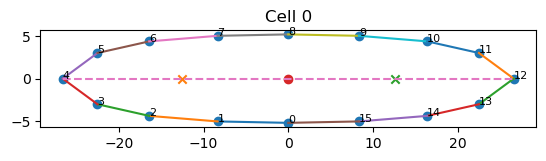

step    0: ar=4.060  orient=0.0°  a_sf=0.4599  RhoA=0.473  RhoC=0.593  
step   50: ar=4.226  orient=0.0°  a_sf=0.4600  RhoA=0.478  RhoC=0.594  
step  100: ar=4.127  orient=180.0°  a_sf=0.4603  RhoA=0.478  RhoC=0.594  
step  150: ar=4.248  orient=180.0°  a_sf=0.4606  RhoA=0.477  RhoC=0.593  
step  200: ar=4.025  orient=180.0°  a_sf=0.4608  RhoA=0.477  RhoC=0.593  
step  250: ar=3.919  orient=180.0°  a_sf=0.4610  RhoA=0.478  RhoC=0.595  
step  300: ar=3.920  orient=180.0°  a_sf=0.4615  RhoA=0.475  RhoC=0.594  
step  350: ar=4.219  orient=180.0°  a_sf=0.4615  RhoA=0.474  RhoC=0.593  
step  400: ar=4.204  orient=0.0°  a_sf=0.4615  RhoA=0.477  RhoC=0.594  
step  450: ar=4.126  orient=0.0°  a_sf=0.4614  RhoA=0.477  RhoC=0.594  
step  500: ar=4.179  orient=0.0°  a_sf=0.4614  RhoA=0.475  RhoC=0.594  
step  550: ar=4.130  orient=-180.0°  a_sf=0.4614  RhoA=0.478  RhoC=0.594  
step  600: ar=3.945  orient=-180.0°  a_sf=0.4615  RhoA=0.475  RhoC=0.593  
step  650: ar=3.987  orient=0.0°  a_sf=0.4616 

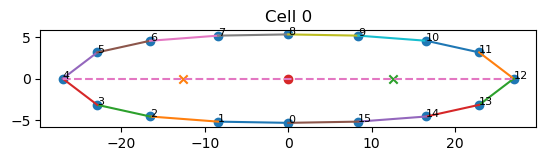


Final: EndothelialCell(id=0 | ar=4.17 | area=1.034 | a_sf=0.460 | RhoA=0.471 RhoC=0.593)


In [5]:

history, forces = run_sim_test(cell, 5000)

In [6]:
pd.DataFrame(forces)

,shear_fn_pole,shear_fn_lat,shear_fn_diff,cortex_T_pole,cortex_T_lat,cortex_k_pole,cortex_k_lat,sf_tension,sf_node_max,sf_squeeze_max,a_sf,fa_force,area_pressure,step
0,8.957,1.151,7.806,2.341,3.383,2.344,1.0,5.163,2.5816,2.5816,0.4599,2.354,0.0000,0
1,8.968,1.283,7.685,2.438,3.393,2.416,1.0,5.167,2.5834,2.5834,0.4600,3.650,4.1781,50
2,9.064,1.256,7.808,2.565,3.408,2.414,1.0,5.191,2.5954,2.5954,0.4603,3.417,0.0000,100
3,8.967,1.246,7.721,2.393,3.397,2.401,1.0,5.168,2.5838,2.5838,0.4606,3.713,5.7618,150
4,8.953,1.235,7.718,2.375,3.395,2.398,1.0,5.169,2.5844,2.5844,0.4608,2.337,0.0000,200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,8.902,1.055,7.847,2.406,3.435,2.285,1.0,5.266,2.6328,2.6328,0.4598,3.669,6.9974,4750
96,8.839,1.026,7.813,2.399,3.421,2.266,1.0,5.276,2.6379,2.6379,0.4597,0.039,0.0000,4800
97,9.014,1.191,7.823,2.664,3.466,2.376,1.0,5.287,2.6437,2.6437,0.4598,3.513,0.0000,4850
98,9.087,1.059,8.028,2.963,3.458,2.295,1.0,5.373,2.6866,2.6866,0.4598,2.478,0.0000,4900


In [6]:
cell.nodes

[MembraneNode(id=0 | role=lateral | pos=[ 0.   -5.16] | f_normal=0.000 | P_RhoA=0.377 P_RhoC=0.587),
 MembraneNode(id=1 | role=lateral | pos=[-0.44 -6.83] | f_normal=6.409 | P_RhoA=0.589 P_RhoC=0.601),
 MembraneNode(id=2 | role=lateral | pos=[-6.45 -8.1 ] | f_normal=1.212 | P_RhoA=0.389 P_RhoC=0.586),
 MembraneNode(id=3 | role=upstream | pos=[-14.16  -5.56] | f_normal=8.954 | P_RhoA=0.596 P_RhoC=0.598),
 MembraneNode(id=4 | role=upstream | pos=[-17.35  -0.  ] | f_normal=15.000 | P_RhoA=0.600 P_RhoC=0.597),
 MembraneNode(id=5 | role=upstream | pos=[-14.16   5.56] | f_normal=8.954 | P_RhoA=0.596 P_RhoC=0.598),
 MembraneNode(id=6 | role=lateral | pos=[-6.45  8.1 ] | f_normal=1.212 | P_RhoA=0.389 P_RhoC=0.586),
 MembraneNode(id=7 | role=lateral | pos=[-0.44  6.83] | f_normal=6.409 | P_RhoA=0.589 P_RhoC=0.601),
 MembraneNode(id=8 | role=lateral | pos=[0.   5.16] | f_normal=0.000 | P_RhoA=0.377 P_RhoC=0.587),
 MembraneNode(id=9 | role=lateral | pos=[0.44 6.83] | f_normal=6.409 | P_RhoA=0.589

In [8]:
cell.nodes

[MembraneNode(id=0 | role=lateral | pos=[ 0.   -3.47] | f_normal=0.000 | P_RhoA=0.378 P_RhoC=0.585),
 MembraneNode(id=1 | role=lateral | pos=[-10.65  -3.46] | f_normal=0.057 | P_RhoA=0.378 P_RhoC=0.585),
 MembraneNode(id=2 | role=lateral | pos=[-21.26  -3.38] | f_normal=0.504 | P_RhoA=0.378 P_RhoC=0.585),
 MembraneNode(id=3 | role=upstream | pos=[-31.57  -2.75] | f_normal=2.601 | P_RhoA=0.451 P_RhoC=0.602),
 MembraneNode(id=4 | role=upstream | pos=[-38.13  -0.  ] | f_normal=15.000 | P_RhoA=0.591 P_RhoC=0.592),
 MembraneNode(id=5 | role=upstream | pos=[-31.57   2.75] | f_normal=2.601 | P_RhoA=0.451 P_RhoC=0.602),
 MembraneNode(id=6 | role=lateral | pos=[-21.26   3.38] | f_normal=0.504 | P_RhoA=0.378 P_RhoC=0.585),
 MembraneNode(id=7 | role=lateral | pos=[-10.65   3.46] | f_normal=0.057 | P_RhoA=0.378 P_RhoC=0.585),
 MembraneNode(id=8 | role=lateral | pos=[-0.    3.47] | f_normal=0.000 | P_RhoA=0.378 P_RhoC=0.585),
 MembraneNode(id=9 | role=lateral | pos=[10.65  3.46] | f_normal=0.057 | 

# Component Tests

### Node Test

In [5]:
# Pole node — high f_normal
n_pole = MembraneNode(0, np.array([12.0, 0.0]), lut, CFG)
n_pole.f_normal = CFG['flow']['f_magnitude']
n_pole.update_signalling()
print(f"Pole node:  f_normal={n_pole.f_normal:.3f} "
      f"P_RhoA={n_pole.P_RhoA:.3f} P_RhoC={n_pole.P_RhoC:.3f}")

# Flank node — zero f_normal
n_flank = MembraneNode(1, np.array([0.0, 12.0]), lut, CFG)
n_flank.f_normal = 0.0
n_flank.update_signalling()
print(f"Flank node: f_normal={n_flank.f_normal:.3f} "
      f"P_RhoA={n_flank.P_RhoA:.3f} P_RhoC={n_flank.P_RhoC:.3f}")

# Pole should have higher RhoA than flank
assert n_pole.P_RhoA > n_flank.P_RhoA, "Pole should have higher RhoA"
#assert n_pole.P_RhoC < n_flank.P_RhoC, "Flank should have higher RhoC"
print("MembraneNode signalling: PASS")

Pole node:  f_normal=15.000 P_RhoA=0.722 P_RhoC=0.300
Flank node: f_normal=0.000 P_RhoA=0.463 P_RhoC=0.437
MembraneNode signalling: PASS


### Spring Test

In [8]:
flow = np.array([1.0, 0.0])

n1 = MembraneNode(0, np.array([0.0, 0.0]), lut, CFG)
n2 = MembraneNode(1, np.array([5.0, 0.0]), lut, CFG)
s  = Spring(0, n1, n2, rest_length=5.0,
            k_cortex=CFG['mechanics']['k_cortex'],
            lut=lut, cfg=CFG)
s._init_alignment = 1.0

# Test 1 — at rest, no RhoA
s.update_geometry(flow)
s.update_cortex()
print(f"At rest:    T={s.t_cortex:.4f}  k={s.k_active:.4f}")
assert abs(s.t_cortex) < 1e-6

# Test 2 — stretched, no RhoA
n2.pos = np.array([7.0, 0.0])
s.update_geometry(flow)
s.update_cortex()
print(f"Stretched:  T={s.t_cortex:.4f}  k={s.k_active:.4f}")
assert s.t_cortex > 0

# Test 3 — stretched, high RhoA at both nodes
n1.P_RhoA = 0.7
n2.P_RhoA = 0.7
s.update_geometry(flow)
s.update_cortex()
print(f"High RhoA:  T={s.t_cortex:.4f}  k={s.k_active:.4f}")
assert s.k_active > CFG['mechanics']['k_cortex']

# Test 4 — asymmetric RhoA
n1.P_RhoA = 0.7
n2.P_RhoA = lut.rhoa_rest
s.update_geometry(flow)
s.update_cortex()
k_asym = s.k_active
n1.P_RhoA = 0.7
n2.P_RhoA = 0.7
s.update_geometry(flow)
s.update_cortex()
k_high = s.k_active
print(f"Asymmetric k={k_asym:.4f}  both-high k={k_high:.4f}  "
      f"(asymmetric should be between baseline and both-high)")
assert CFG['mechanics']['k_cortex'] < k_asym < k_high

# Test 5 — force application
n1.force = np.zeros(2)
n2.force = np.zeros(2)
n2.pos = np.array([7.0, 0.0])
s.update_geometry(flow)
s.update_cortex()
s.apply_forces()
print(f"Node1 force: {n1.force.round(4)}")
print(f"Node2 force: {n2.force.round(4)}")
assert np.allclose(n1.force, -n2.force)

print("Spring: PASS")

At rest:    T=0.0000  k=1.0000
Stretched:  T=2.0000  k=1.0000
High RhoA:  T=9.1100  k=4.5550
Asymmetric k=2.7775  both-high k=4.5550  (asymmetric should be between baseline and both-high)
Node1 force: [9.11 0.  ]
Node2 force: [-9.11  0.  ]
Spring: PASS


### Stress Fibre Tests

In [10]:
up = MembraneNode(0, np.array([-12.0, 0.0]), lut, CFG)
dn = MembraneNode(1, np.array([ 12.0, 0.0]), lut, CFG)
sf = StressFibre(up, dn, CFG)

nodes = [
    MembraneNode(2, np.array([ 0.0,  12.0]), lut, CFG),  # top flank
    MembraneNode(3, np.array([ 0.0, -12.0]), lut, CFG),  # bottom flank
    MembraneNode(4, np.array([ 0.0,   6.0]), lut, CFG),  # mid flank
    MembraneNode(5, np.array([12.0,   0.0]), lut, CFG),  # pole
]

# Test 1 — no a_sf
sf.a_sf = 0.0
sf.update_geometry_and_tension()
assert sf.t_sf == 0.0
print(f"No a_sf: t_sf={sf.t_sf:.4f} ✓")

# Test 2 — full a_sf, cable tension
sf.a_sf = 1.0
sf.update_geometry_and_tension()
print(f"Full a_sf: L={sf.L_current:.3f}  t_sf={sf.t_sf:.4f}")
assert sf.t_sf == sf.k_sf * 1.0 * sf.L_current

# Test 3 — cable forces
up.force = np.zeros(2)
dn.force = np.zeros(2)
sf.apply_forces()
assert np.allclose(up.force, -dn.force)
assert up.force[0] > 0
assert dn.force[0] < 0
print(f"Cable forces: up={up.force.round(3)}  dn={dn.force.round(3)} ✓")

# Test 4 — squeeze
max_y = max(abs(n.pos[1] - sf.cable_y) for n in nodes)
for node in nodes:
    f = sf.get_squeeze_force(node.pos[1], max_y)
    node.apply_force(np.array([0.0, f]))
    print(f"  y={node.pos[1]:+6.1f}  squeeze={f:+.4f}")

assert nodes[0].force[1] < 0      # top flank pushed down
assert nodes[1].force[1] > 0      # bottom flank pushed up
assert abs(nodes[3].force[1]) < 1e-6  # pole: no squeeze
assert abs(nodes[0].force[1]) > abs(nodes[2].force[1])  # flank > mid

print("StressFibre: PASS")

No a_sf: t_sf=0.0000 ✓
Full a_sf: L=24.000  t_sf=0.5000


AssertionError: 

In [5]:
np.mean([n_pole.P_RhoA, n_flank.P_RhoA])

np.float64(0.5535)

# Cell Tests

### Node Initialisation Test

In [2]:
cell = EndothelialCell(0, np.array([0.0, 0.0]),
                       lut=lut, cfg=CFG,
                       n_nodes=CFG['sim']['n_nodes'],
                       radius=CFG['sim']['radius'])

In [4]:

# Node classification
roles = [n.role for n in cell.nodes]
print(f"upstream={roles.count('upstream')}  "
      f"downstream={roles.count('downstream')}  "
      f"lateral={roles.count('lateral')}")
assert roles.count('upstream')   == 3
assert roles.count('downstream') == 3
assert roles.count('lateral')    == 10

# FA nodes
print(f"FA nodes: {len(cell.fa_nodes)} "
      f"(ids: {list(cell.fa_nodes.keys())})")
assert len(cell.fa_nodes) == 2

# SF cables
print(f"SF cables: {len(cell.stress_fibres)}")
for sf in cell.stress_fibres:
    print(f"  {sf}")
assert len(cell.stress_fibres) == 1

# Area
print(f"Area: {cell.target_area:.1f} units² = "
      f"{cell.target_area*9:.0f} µm²")

print("EndothelialCell init: PASS")

upstream=3  downstream=3  lateral=10
FA nodes: 2 (ids: [4, 12])
SF cables: 1
  StressFibre(L=0.000 | contractility=0.000 | T_sf=0.0000 | cable_y=0.000)
Area: 440.9 units² = 3968 µm²
EndothelialCell init: PASS


### Node Force Methods

In [6]:

flow = FlowField(magnitude=CFG['mechanics']['f_magnitude'])
cell = EndothelialCell(0, np.array([0.0, 0.0]),
                       lut=lut, cfg=CFG,
                       n_nodes=CFG['sim']['n_nodes'],
                       radius=CFG['sim']['radius'])

# Test 1 — shear: no translation, f_normal highest at poles
cell._apply_shear(flow)
net = sum(n.force for n in cell.nodes)
print(f"Net force after shear: {net.round(6)}")
assert np.allclose(net, 0, atol=1e-6), "Net force must be zero"

pole_fn   = np.mean([n.f_normal for n in cell.nodes
                     if n.role in ('upstream','downstream')])
flank_fn  = np.mean([n.f_normal for n in cell.nodes
                     if n.role == 'lateral'])
print(f"Pole f_normal={pole_fn:.3f}  Flank f_normal={flank_fn:.3f}")
assert pole_fn > flank_fn, "Poles should have higher f_normal"

# Reset forces
for n in cell.nodes: n.force = np.zeros(2)

# Test 2 — FA anchoring: pole nodes at rest position → zero force
cell._apply_fa_anchoring()
pole_forces = [np.linalg.norm(cell.nodes[i].force)
               for i in range(cell.n_nodes)
               if cell.nodes[i].id in cell.fa_nodes]
print(f"FA forces at rest: {[round(f,6) for f in pole_forces]}")
assert all(f < 1e-6 for f in pole_forces), "No FA force when at rest pos"

# Reset
for n in cell.nodes: n.force = np.zeros(2)

# Test 3 — SF squeeze: flanks squeezed, poles unaffected
for sf in cell.stress_fibres:
    sf.a_sf = 1.0
    sf.update_geometry_and_tension()

cell._apply_sf_squeeze()
lateral_y = [abs(cell.nodes[i].force[1])
             for i in range(cell.n_nodes)
             if cell.nodes[i].role == 'lateral']
pole_y    = [abs(cell.nodes[i].force[1])
             for i in range(cell.n_nodes)
             if cell.nodes[i].role in ('upstream','downstream')]
print(f"Mean lateral squeeze: {np.mean(lateral_y):.4f}")
print(f"Mean pole squeeze:    {np.mean(pole_y):.4f}")
assert np.mean(lateral_y) > np.mean(pole_y), \
    "Lateral nodes should feel more squeeze than poles"

print("Force methods: PASS")

Net force after shear: [0. 0.]
Pole f_normal=2.848  Flank f_normal=1.308
FA forces at rest: [np.float64(0.0), np.float64(0.0)]
Mean lateral squeeze: 0.2557
Mean pole squeeze:    0.0765
Force methods: PASS


0.65

# SIM Tests

### Simulation Test

In [7]:
flow = FlowField(magnitude=CFG['mechanics']['f_magnitude'])
cell = EndothelialCell(0, np.array([0.0, 0.0]),
                       lut=lut, cfg=CFG,
                       n_nodes=CFG['sim']['n_nodes'],
                       radius=CFG['sim']['radius'])
print("\nRunning 100 steps...")
for step in range(100):
    cell.step(flow, dt=CFG['sim']['dt'])
    if step % 20 == 0:
        s = cell.get_state()
        print(f"  step {step:>4}: ar={s['ar']:.3f}  "
              f"orient={s['orientation']:.1f}°  "
              f"a_sf={s['a_sf']:.4f}  "
              f"RhoA={s['mean_rhoa']:.3f}  "
              f"RhoC={s['mean_rhoc']:.3f}  "
              f"area={s['area_err']:.3f}")

s = cell.get_state()
print(f"\nFinal: {cell}")
assert s['ar'] > 1.0,           "Cell should elongate"
assert abs(s['orientation']) < 45 or abs(s['orientation']) > 135, \
    "Elongation should be along flow axis"
assert 0.9 < s['area_err'] < 1.1, "Area should be conserved"
print("Full simulation: PASS")


Running 100 steps...
  step    0: ar=1.000  orient=0.0°  a_sf=0.0016  RhoA=0.590  RhoC=0.610  area=1.000
  step   20: ar=1.002  orient=90.0°  a_sf=0.0320  RhoA=0.590  RhoC=0.610  area=0.173
  step   40: ar=1.022  orient=-180.0°  a_sf=0.0597  RhoA=0.605  RhoC=0.602  area=0.259
  step   60: ar=1.029  orient=90.0°  a_sf=0.0853  RhoA=0.603  RhoC=0.598  area=0.879
  step   80: ar=1.027  orient=90.0°  a_sf=0.1089  RhoA=0.605  RhoC=0.602  area=0.879

Final: EndothelialCell(id=0 | ar=1.02 | area_err=0.996 | a_sf=0.130 | RhoA=0.605 RhoC=0.602)


AssertionError: Elongation should be along flow axis

### Sim Perturbation Tests

In [2]:
import copy

conditions = {
    'WT':            {},
    'DSP_KO':        {'DSP':  {'knocked_out': True}},
    'TJP1_KO':       {'TJP1': {'knocked_out': True}},
    'JCAD_KO': {'JCAD': {'knocked_out': True}},
    'DSP_JCAD_DKO':  {'DSP':  {'knocked_out': True},
                      'JCAD': {'knocked_out': True}},
    'TJP1_JCAD_DKO': {'TJP1': {'knocked_out': True},
                      'JCAD': {'knocked_out': True}},
}

def run_condition(cfg, lut, knockouts, n_steps=1500):
      c = copy.deepcopy(cfg)
      for protein, overrides in knockouts.items():
            c['hill_params'][protein].update(overrides)

      cell = EndothelialCell(0, np.array([0.0, 0.0]),
                              lut=lut, cfg=c,
                              n_nodes=c['cell_geometry']['n_nodes'],
                              radius=c['cell_geometry']['radius'])
      
      flow = FlowField(magnitude=c['flow']['f_magnitude'])
      for _ in range(n_steps):
            cell.step(flow, dt=c['integration']['dt'])
      #plot_cell(cell)
      return cell.get_state()


print(f"{'Condition':<18} {'AR':>6} {'orient':>8} "
      f"{'a_sf':>6} {'RhoA':>6} {'RhoC':>6} {'area':>6}")
print("-" * 60)

results = {}
for name, knockouts in conditions.items():
    s = run_condition(CFG, lut, knockouts, n_steps=1500)
    results[name] = s
    print(f"{name:<18} {s['ar']:>6.3f} {s['orientation']:>8.1f}° "
          f"{s['a_sf']:>6.3f} {s['mean_rhoa']:>6.3f} "
          f"{s['mean_rhoc']:>6.3f}")

# Check primary ordering
print("\nOrdering checks:")
print(f"TJP1_KO < WT:    {results['TJP1_KO']['ar']:.3f} < {results['WT']['ar']:.3f} "
      f"→ {'✓' if results['TJP1_KO']['ar'] < results['WT']['ar'] else '✗'}")
print(f"WT < DSP_KO:     {results['WT']['ar']:.3f} < {results['DSP_KO']['ar']:.3f} "
      f"→ {'✓' if results['WT']['ar'] < results['DSP_KO']['ar'] else '✗'}")
print(f"TJP1_KO < TJP1_JCAD: {results['TJP1_KO']['ar']:.3f} < "
      f"{results['TJP1_JCAD_DKO']['ar']:.3f} "
      f"→ {'✓' if results['TJP1_KO']['ar'] < results['TJP1_JCAD_DKO']['ar'] else '✗'}")
print(f"TJP1_JCAD < WT:  {results['TJP1_JCAD_DKO']['ar']:.3f} < {results['WT']['ar']:.3f} "
      f"→ {'✓' if results['TJP1_JCAD_DKO']['ar'] < results['WT']['ar'] else '✗'}")

Condition              AR   orient   a_sf   RhoA   RhoC   area
------------------------------------------------------------
WT                  2.866   -180.0°  0.462  0.503  0.595
DSP_KO              3.937    180.0°  0.646  0.341  0.656
TJP1_KO             2.066      0.0°  0.000  0.659  0.337
JCAD_KO             3.700      0.0°  0.308  0.451  0.543
DSP_JCAD_DKO        3.861    180.0°  0.439  0.377  0.587
TJP1_JCAD_DKO       2.528      0.0°  0.000  0.542  0.409

Ordering checks:
TJP1_KO < WT:    2.066 < 2.866 → ✓
WT < DSP_KO:     2.866 < 3.937 → ✓
TJP1_KO < TJP1_JCAD: 2.066 < 2.528 → ✓
TJP1_JCAD < WT:  2.528 < 2.866 → ✓


## DEBUG

In [3]:
# One-step force audit on fresh cell
cell_audit = EndothelialCell(0, np.array([0.0, 0.0]),
                              lut=lut, cfg=CFG,
                              n_nodes=CFG['sim']['n_nodes'],
                              radius=CFG['sim']['radius'])

# Force a_sf for SF visibility
for sf in cell_audit.stress_fibres:
    sf.a_sf = 0.8
    sf.update_geometry_and_tension()

# Apply each force separately and print
def print_forces(label, nodes_of_interest):
    print(f"\n--- {label} ---")
    print(f"{'id':>3} {'role':>12} {'fx':>8} {'fy':>8}")
    for node in nodes_of_interest:
        print(f"{node.id:>3} {node.role:>12} "
              f"{node.force[0]:>8.4f} {node.force[1]:>8.4f}")

# Reset
for n in cell_audit.nodes: n.force = np.zeros(2)
cell_audit._apply_shear(flow)
poles  = [n for n in cell_audit.nodes if n.role in ('upstream','downstream')]
flanks = [n for n in cell_audit.nodes if n.role == 'lateral']
print_forces("1. DRAG (poles only)", poles[:2] + [poles[-1]])

for n in cell_audit.nodes: n.force = np.zeros(2)
for s in cell_audit.springs:
    s.update_geometry(cell_audit.flow_direction)
    s.update_cortex()
    s.apply_forces()
print_forces("2. CORTEX SPRINGS (pole + flank sample)",
             [cell_audit.nodes[4], cell_audit.nodes[0], cell_audit.nodes[8]])

for n in cell_audit.nodes: n.force = np.zeros(2)
for sf in cell_audit.stress_fibres:
    sf.apply_forces()
print_forces("3. SF CABLE (pole nodes)", poles)

for n in cell_audit.nodes: n.force = np.zeros(2)
cell_audit._apply_sf_squeeze()
print_forces("4. SF SQUEEZE (flank sample)",
             [cell_audit.nodes[0], cell_audit.nodes[8]])

for n in cell_audit.nodes: n.force = np.zeros(2)
cell_audit._apply_fa_anchoring()
print_forces("5. FA ANCHORING (pole nodes)", poles)



--- 1. DRAG (poles only) ---
 id         role       fx       fy
  3     upstream  -0.1000   0.0000
  4     upstream  -0.1000   0.0000
 13   downstream   0.1000   0.0000

--- 2. CORTEX SPRINGS (pole + flank sample) ---
 id         role       fx       fy
  4     upstream  -0.0440   0.0000
  0      lateral   0.0000  -0.2606
  8      lateral   0.0000   0.2606

--- 3. SF CABLE (pole nodes) ---
 id         role       fx       fy
  3     upstream   0.0000   0.0000
  4     upstream   0.5520  -0.0000
  5     upstream   0.0000   0.0000
 11   downstream   0.0000   0.0000
 12   downstream  -0.5520   0.0000
 13   downstream   0.0000   0.0000

--- 4. SF SQUEEZE (flank sample) ---
 id         role       fx       fy
  0      lateral   0.0000  -0.2400
  8      lateral   0.0000   0.2400

--- 5. FA ANCHORING (pole nodes) ---
 id         role       fx       fy
  3     upstream   0.0000   0.0000
  4     upstream   0.0000   0.0000
  5     upstream   0.0000   0.0000
 11   downstream   0.0000   0.0000
 12   